# **FGVCAircraft  - CLIP Prompt Tuning - CuPL**

In [ ]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-34_h1vpa
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-34_h1vpa
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=7e93f1f87bde1922d1a67112e3199fbb9ebd571c3ee764e37fd4bdd1d4a2b81b
  Stored in directory: /tmp/pip-ephem-wheel-cache-6q1ekxqw/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


### Imports and  loading FGCVAircraft data

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import clip
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tqdm import tqdm
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [ ]:
class FGVCAircraftDataset(Dataset):
    def __init__(self, root, split="train", transform=None):
        self.root = root
        self.transform = transform

        with open(os.path.join(root, "variants.txt")) as f:
            self.classes = [line.strip() for line in f.readlines()]

        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        split_file = os.path.join(root, f"images_variant_{split}.txt")
        self.samples = []

        with open(split_file) as f:
            for line in f:
                parts = line.strip().split(" ")
                img_name = parts[0]
                label = " ".join(parts[1:])
                img_path = os.path.join(root, "images", f"{img_name}.jpg")

                if label in self.class_to_idx:
                    self.samples.append((img_path, self.class_to_idx[label]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert("RGB")
        except:
            image = Image.new("RGB", (224, 224))

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
#ensures that the images are in the exact format that CLIP was trained on. If this is skipped, then accuracy will drop significantly.
clip_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.48145466, 0.4578275, 0.40821073),
        std=(0.26862954, 0.26130258, 0.27577711),
    ),
])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r "/content/drive/MyDrive/Colab Notebooks/EEEM068 - Applied Machine Learning/COURSEWORK/data" /content/data
root = "/content/data"

In [ ]:
train_dataset = FGVCAircraftDataset(root, "train", clip_transform)
val_dataset   = FGVCAircraftDataset(root, "val", clip_transform)
test_dataset  = FGVCAircraftDataset(root, "test", clip_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64)
test_loader  = DataLoader(test_dataset, batch_size=64)

classnames = train_dataset.classes

print("Classes:", len(classnames))

Classes: 100


### Load CLIP and Models

In [ ]:
model, _ = clip.load("ViT-B/16", device=device)
model.eval()

100%|███████████████████████████████████████| 335M/335M [00:04<00:00, 70.9MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

##### CuPL

In [ ]:
cupl_templates = [
    "a detailed photo of a {}, a type of aircraft",
    "a high resolution image of a {} airplane",
    "an aircraft model known as {}",
    "a side view of a {} aircraft"
]

def cupl_classifier(classnames):
    feats = []
    for t in cupl_templates:
        feats.append(zero_shot_classifier(classnames, t))
    return torch.stack(feats).mean(dim=0)

### Evaluate

##### Evaluation Function

In [ ]:
def evaluate(text_features, dataloader, name="Model"):
    correct1, correct5, total = 0, 0, 0
    y_true, y_pred = [], []

    print(f"\nEvaluating {name}...")
    start_time = time.time()

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f"{name} Progress"):
            images = images.to(device)
            labels = labels.to(device)

            image_features = model.encode_image(images)
            image_features /= image_features.norm(dim=-1, keepdim=True)

            text_features = text_features.to(image_features.dtype)
            #logits = image_features @ text_features.T

            logits = image_features @ text_features.T
### use both top1 and top5 accuracies because the airplane classes are very similar
            # Top-1
            preds = logits.argmax(dim=1)
            correct1 += (preds == labels).sum().item()

            # Top-5
            # is the correct answer in the first 5 guesses
            top5 = logits.topk(5, dim=1).indices
            correct5 += sum([labels[i] in top5[i] for i in range(len(labels))])

            total += labels.size(0)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    end_time = time.time()
    print(f"{name} completed in {end_time - start_time:.2f} seconds")

    return correct1/total, correct5/total, y_true, y_pred

In [ ]:
def evaluate_prompt_variance(classnames, templates, dataloader, name="Model"):
    top1_scores = []
    top5_scores = []

    print(f"\nEvaluating variance for {name}...")

    for i, t in enumerate(templates):
        print(f"\nTemplate {i+1}/{len(templates)}: {t}")

        # Build text features for this prompt
        text_features = zero_shot_classifier(classnames, t)

        #evaluation function
        top1, top5, _, _ = evaluate(
            text_features,
            dataloader,
            name=f"{name} | Prompt {i+1}"
        )

        top1_scores.append(top1)
        top5_scores.append(top5)

    # Compute statistics
    mean_top1 = np.mean(top1_scores)
    var_top1  = np.var(top1_scores)

    mean_top5 = np.mean(top5_scores)
    var_top5  = np.var(top5_scores)

    print("\n===== VARIANCE RESULTS =====")
    print(f"{name} Mean Top-1: {mean_top1:.4f}")
    print(f"{name} Var  Top-1: {var_top1:.6f}")
    print(f"{name} Mean Top-5: {mean_top5:.4f}")
    print(f"{name} Var  Top-5: {var_top5:.6f}")

    return {
        "top1_scores": top1_scores,
        "top5_scores": top5_scores,
        "mean_top1": mean_top1,
        "var_top1": var_top1,
        "mean_top5": mean_top5,
        "var_top5": var_top5
    }

##### Evaluation Metrics

In [ ]:
results = {}

In [ ]:
# CuPL
cupl_features = cupl_classifier(classnames)
results["CuPL"] = evaluate(cupl_features, test_loader)


Evaluating Model...


Model Progress: 100%|██████████| 53/53 [01:02<00:00,  1.19s/it]

Model completed in 62.94 seconds


In [ ]:
cupl_prompt_results = evaluate_prompt_variance(classnames,cupl_templates,test_loader,name="CuPL")


Evaluating variance for CuPL...

Template 1/4: a detailed photo of a {}, a type of aircraft

Evaluating CuPL | Prompt 1...


CuPL | Prompt 1 Progress: 100%|██████████| 53/53 [01:02<00:00,  1.19s/it]


CuPL | Prompt 1 completed in 62.86 seconds

Template 2/4: a high resolution image of a {} airplane

Evaluating CuPL | Prompt 2...


CuPL | Prompt 2 Progress: 100%|██████████| 53/53 [01:01<00:00,  1.17s/it]


CuPL | Prompt 2 completed in 61.88 seconds

Template 3/4: an aircraft model known as {}

Evaluating CuPL | Prompt 3...


CuPL | Prompt 3 Progress: 100%|██████████| 53/53 [01:02<00:00,  1.18s/it]


CuPL | Prompt 3 completed in 62.79 seconds

Template 4/4: a side view of a {} aircraft

Evaluating CuPL | Prompt 4...


CuPL | Prompt 4 Progress: 100%|██████████| 53/53 [01:02<00:00,  1.17s/it]

CuPL | Prompt 4 completed in 62.09 seconds

===== VARIANCE RESULTS =====
CuPL Mean Top-1: 0.2376
CuPL Var  Top-1: 0.000095
CuPL Mean Top-5: 0.5974
CuPL Var  Top-5: 0.000077


##### Evaluation Plots

In [ ]:
for k, v in results.items():
    print(f"{k}: Top-1={v[0]:.4f}, Top-5={v[1]:.4f}")

Zero-shot: Top-1=0.2304, Top-5=0.5848
Ensemble: Top-1=0.2328, Top-5=0.5878
CuPL: Top-1=0.2412, Top-5=0.6091
CoOp: Top-1=0.1851, Top-5=0.4950
CoCoOp: Top-1=0.1131, Top-5=0.3129
KgCoOp: Top-1=0.2046, Top-5=0.5287
PromptSRC: Top-1=0.1872, Top-5=0.4944
MaPLe: Top-1=0.1836, Top-5=0.4977
ProGrad: Top-1=0.1866, Top-5=0.4968


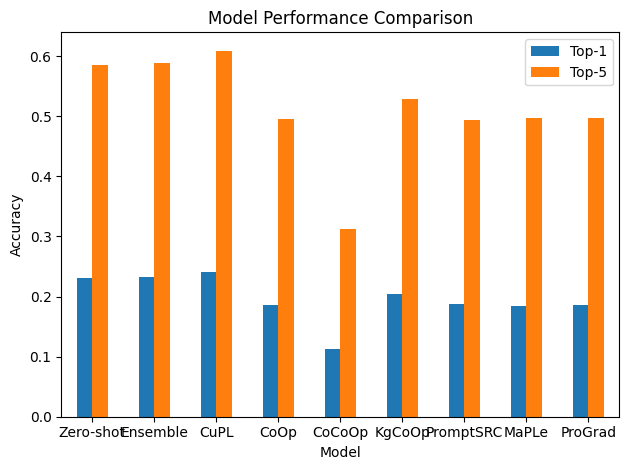

In [ ]:
acc_results = {
    k: (v[0], v[1])  # keep only Top-1 and Top-5 accuracies
    for k, v in results.items()
}
accuracies = pd.DataFrame.from_dict(acc_results,orient='index',columns=["Top-1", "Top-5"])

accuracies.plot(kind='bar')
plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Zero-shot: Top-1=0.2268, Top-5=0.5734


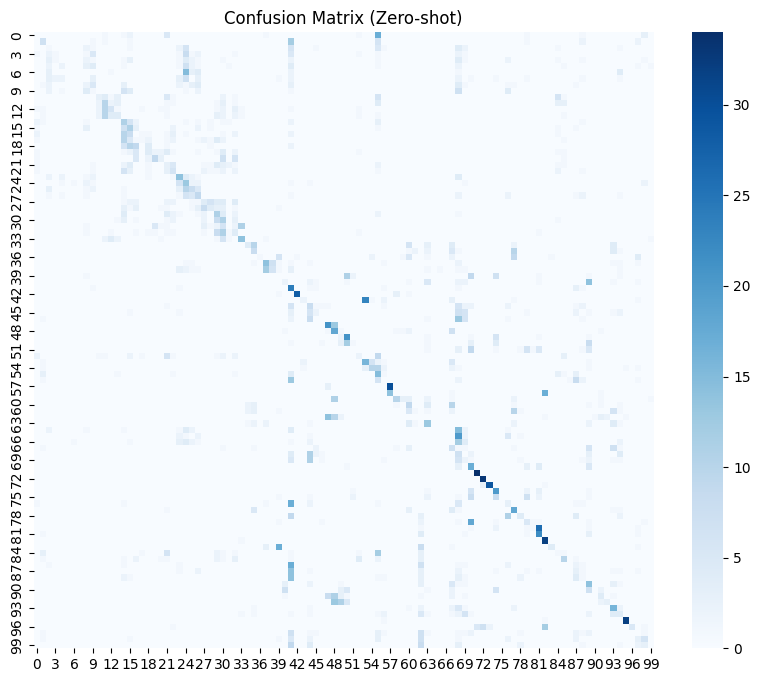

In [ ]:
# CONFUSION MATRIX for one shot
y_true, y_pred = results["CuPL"][2], results["CuPL"][3]
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix (CuPL)")
plt.show()

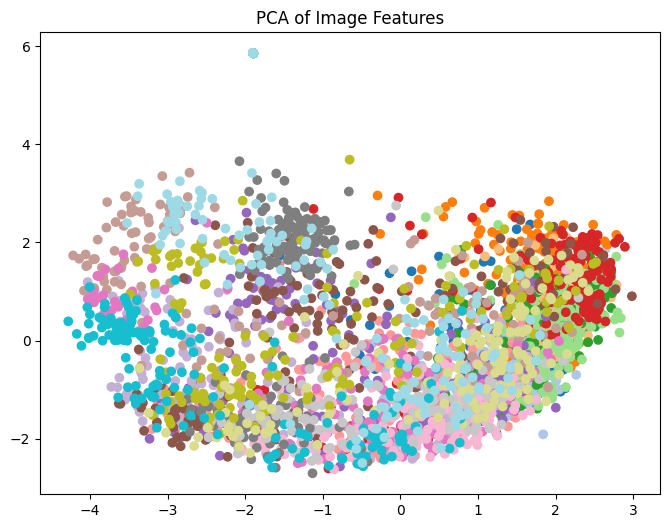

In [ ]:
# Principle Component Analysis - get the most important features
def get_features(dataloader):
    feats, labels = [], []
    with torch.no_grad():
        for images, y in dataloader:
            images = images.to(device)
            f = model.encode_image(images)
            feats.append(f.cpu().numpy())
            labels.extend(y.numpy())
    return np.vstack(feats), np.array(labels)

features, labels = get_features(test_loader)

pca = PCA(n_components=2)
reduced = pca.fit_transform(features)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=labels, cmap='tab20')
plt.title("PCA of Image Features")
plt.show()